In [1]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Connect to the DB
con = duckdb.connect('../data/processed/biocascade.db')
df = con.execute("SELECT * FROM feature_matrix_raw").df()

print(f"✅ Engineering Success: {len(df.columns)} features ready for analysis.")

✅ Engineering Success: 51 features ready for analysis.


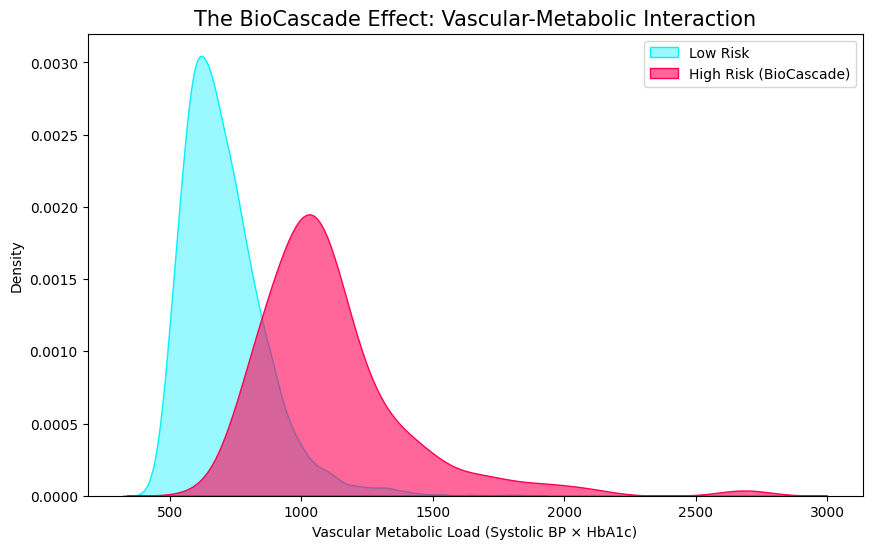

In [2]:
plt.figure(figsize=(10, 6))

# Use the neon colors from our palette
sns.kdeplot(data=df[df['is_high_risk'] == 0], x='vasc_metabolic_load', 
            fill=True, label='Low Risk', color='#00f2ff', alpha=0.4)
sns.kdeplot(data=df[df['is_high_risk'] == 1], x='vasc_metabolic_load', 
            fill=True, label='High Risk (BioCascade)', color='#ff0055', alpha=0.6)

plt.title('The BioCascade Effect: Vascular-Metabolic Interaction', fontsize=15)
plt.xlabel('Vascular Metabolic Load (Systolic BP × HbA1c)')
plt.ylabel('Density')
plt.legend()
plt.show()

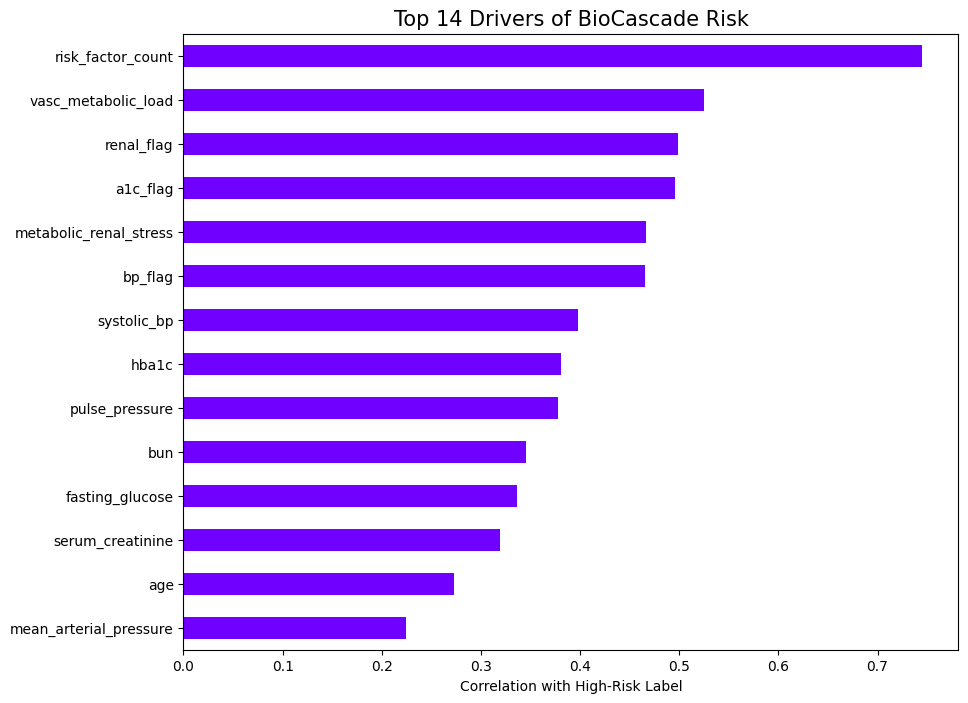

In [3]:
# Calculate correlation of all features with the high-risk label
correlations = df.corr()['is_high_risk'].sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
correlations[1:].plot(kind='barh', color='#7000ff') # Skip the label itself
plt.title('Top 14 Drivers of BioCascade Risk', fontsize=15)
plt.xlabel('Correlation with High-Risk Label')
plt.gca().invert_yaxis()
plt.show()